### Importation des modules

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

### Chargement des données

In [36]:
# Optionnel mais pratique pour l'affichage dans Jupyter
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Charger les informations des chiens
df_dogs = pd.read_excel(r"C:\Users\Cours APT\Documents\dog-behavior-analysis\data\DogInfo.xlsx")
print(f"Nombre de chiens : {len(df_dogs)}")
display(df_dogs.head())

# Charger les séries temporelles relatives à chaque chien / test
na_values = ['<undefined>']

df_ts = pd.read_csv(
    r"C:\Users\Cours APT\Documents\dog-behavior-analysis\data\DogMoveData.csv", 
    na_values=na_values,
    low_memory=False
)

print(f"Dimensions de l'échantillon : {df_ts.shape}")
display(df_ts.head())

Nombre de chiens : 45


,DogID,Breed,Weight,Age months,Gender,NeuteringStatus
0,16,Crossbreed,13,20,1,0
1,18,Belgian Shepherd,29,76,2,0
2,19,German Shepherd,30,57,1,0
3,20,Border Collie,15,47,1,0
4,21,Golden Retriever,39,19,2,0


Dimensions de l'échantillon : (10611068, 20)


,DogID,TestNum,t_sec,ABack_x,ABack_y,ABack_z,ANeck_x,ANeck_y,ANeck_z,GBack_x,GBack_y,GBack_z,GNeck_x,GNeck_y,GNeck_z,Task,Behavior_1,Behavior_2,Behavior_3,PointEvent
0,16,1,0.00,0.041504,0.938965,-0.015137,-0.067871,-0.510254,-0.934570,-17.639161,-22.766115,7.446290,-7.934571,6.347657,13.427735,NaN,NaN,NaN,NaN,NaN
1,16,1,0.01,0.041992,0.941895,-0.020020,-0.128906,-0.494141,-0.913086,-15.075685,-11.413575,4.821778,-3.906250,4.394532,16.540528,NaN,Synchronization,NaN,NaN,NaN
2,16,1,0.02,0.040527,0.939453,-0.004395,-0.158691,-0.480469,-0.911133,-12.207032,-0.122070,2.807617,-0.488281,-1.953125,26.794435,NaN,Synchronization,NaN,NaN,NaN
3,16,1,0.03,0.021484,0.946289,0.007813,-0.122070,-0.486816,-0.880371,-9.460450,7.995606,1.586914,1.159668,-5.676270,38.085940,NaN,Synchronization,NaN,NaN,NaN
4,16,1,0.04,-0.000977,0.951172,0.033691,-0.053711,-0.500000,-0.807129,-8.361817,14.587403,-1.037598,4.577637,4.089356,41.503909,NaN,Synchronization,NaN,NaN,NaN


### Feature engineering : 
- on retire les comportements de "synchronization".
- on créé une nouvelle variable sur la 'taille' du chien (petit, moyen, grand) en fonction de son poids.
- on a déjà retiré les portions de séries temporelles avec valeur de Behavior_1 manquante.

In [37]:
# 1. Définition des seuils de poids (à ajuster selon ta connaissance vétérinaire si besoin)
# Exemple : < 15 kg (Petit), 15 à 30 kg (Moyen), > 30 kg (Grand)
bins = [0, 15, 30, 100] 
labels = ['Taille_Petite', 'Taille_Moyenne', 'Taille_Grande']

# 2. Création de la catégorie textuelle
df_dogs['Taille_Categorie'] = pd.cut(df_dogs['Weight'], bins=bins, labels=labels, right=False)

# 3. Création des colonnes binaires (0 ou 1) via One-Hot Encoding
df_dogs = pd.get_dummies(df_dogs, columns=['Taille_Categorie'], dtype=int)

# Affichage pour vérifier les nouvelles colonnes
display(df_dogs[['DogID', 'Breed', 'Weight', 'Taille_Categorie_Taille_Petite', 'Taille_Categorie_Taille_Moyenne', 'Taille_Categorie_Taille_Grande']].head())

# Liste des comportements techniques à exclure
comportements_a_ignorer = ['Synchronization', 'Extra_Synchronization']

# Filtrage pour ne conserver que les vrais comportements
df_ts = df_ts[~df_ts['Behavior_1'].isin(comportements_a_ignorer)].copy()

# Vérification rapide
print("Comportements conservés pour la modélisation :")
print(df_ts['Behavior_1'].dropna().unique())

,DogID,Breed,Weight,Taille_Categorie_Taille_Petite,Taille_Categorie_Taille_Moyenne,Taille_Categorie_Taille_Grande
0,16,Crossbreed,13,1,0,0
1,18,Belgian Shepherd,29,0,1,0
2,19,German Shepherd,30,0,0,1
3,20,Border Collie,15,0,1,0
4,21,Golden Retriever,39,0,0,1


Comportements conservés pour la modélisation :
<ArrowStringArray>
[        'Walking',         'Shaking',        'Sniffing',          'Eating',
         'Sitting',        'Trotting',          'Pacing',     'Lying chest',
         'Playing',        'Standing',         'Panting',        'Drinking',
       'Galloping', 'Carrying object',         'Tugging',         'Jumping',
          'Bowing']
Length: 17, dtype: str


### Séparation des jeux en train / test + vérification de l'équilibre des classes

=== Répartition des 45 chiens ===
Train : 36 chiens (80.0%)
Test  : 9 chiens (20.0%)
--------------------------------------------------

=== Proportions des classes dans Train et Test ===


,Train (%),Test (%)
Behavior_1,,
Sniffing,15.85,14.97
Lying chest,15.71,15.81
Panting,13.70,9.52
Playing,12.96,13.83
Trotting,11.23,9.96
Walking,10.95,11.67
Sitting,6.80,11.07
Standing,6.52,7.96
Eating,2.97,1.05


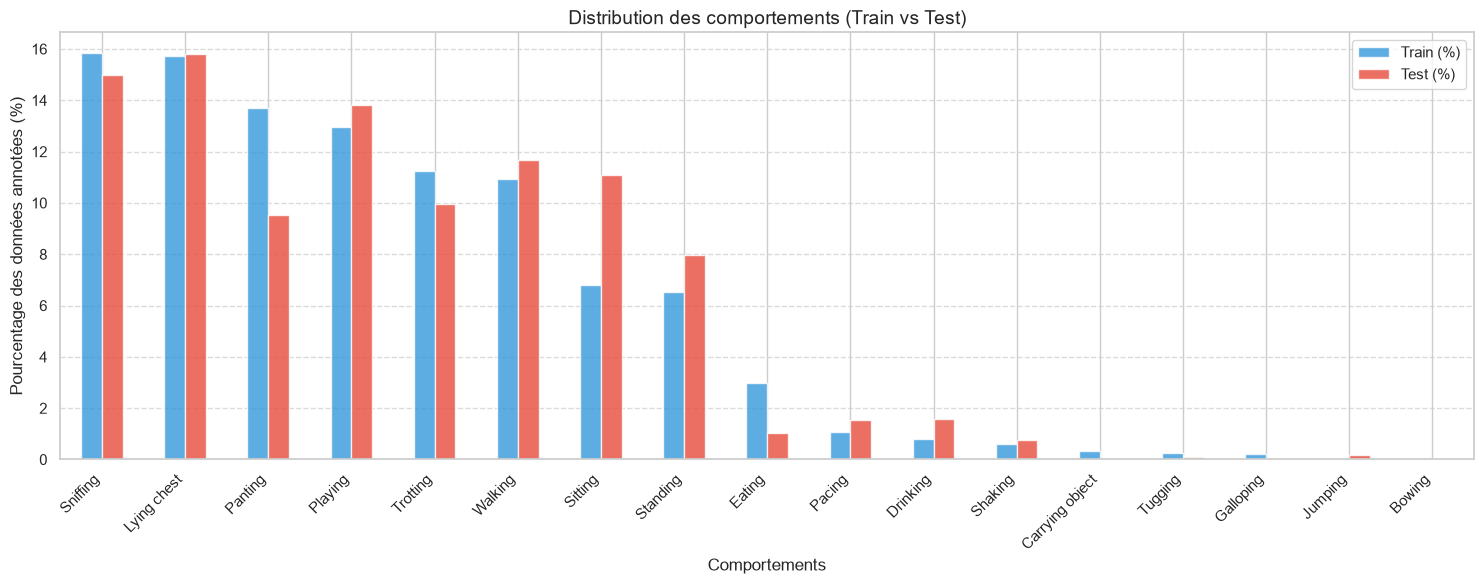

=== Comparaison des profils physiques (Moyennes) ===


,Age months,Weight
Set,,
Test,53.6,21.8
Train,59.2,24.8


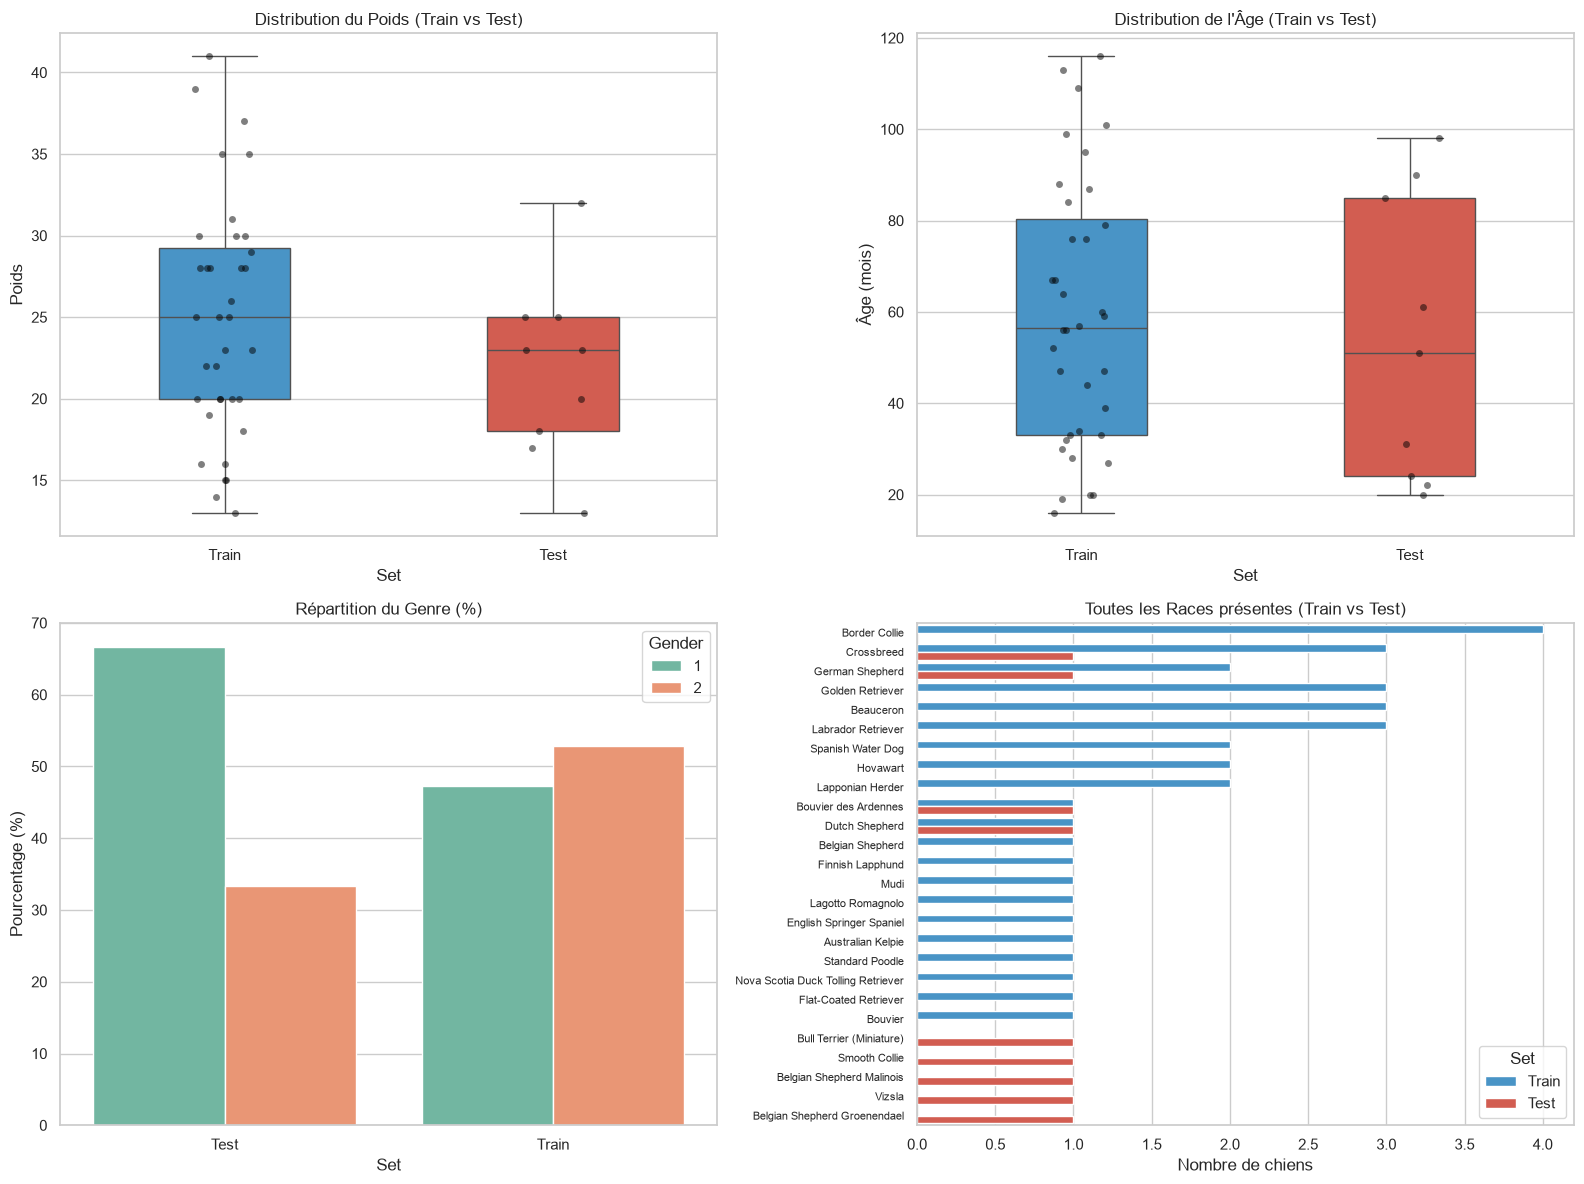

=== Nombre de chiens par catégorie de taille (Train vs Test) ===


,Taille_Categorie_Taille_Petite,Taille_Categorie_Taille_Moyenne,Taille_Categorie_Taille_Grande
Set,,,
Test,1,7,1
Train,2,25,9


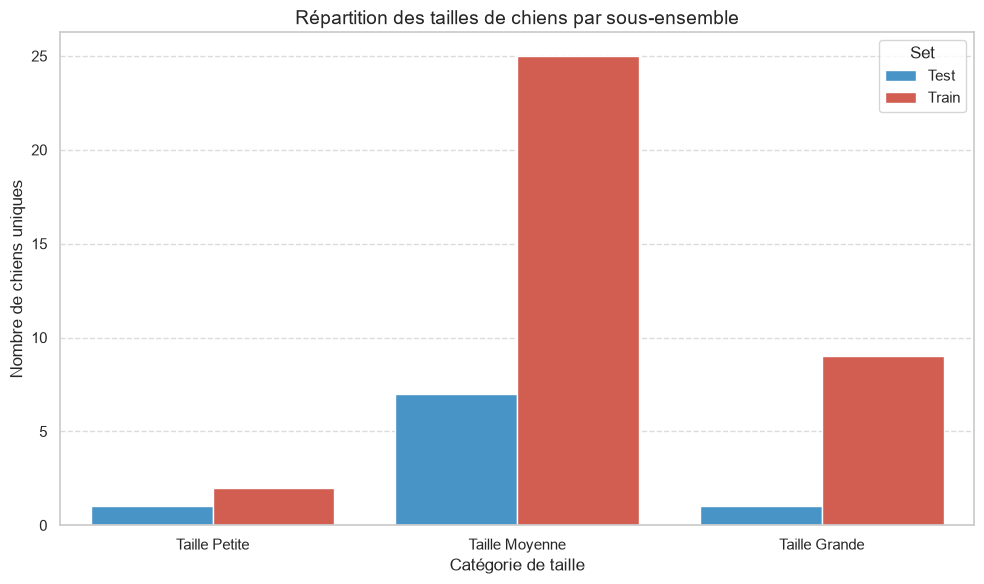

In [38]:
# 1. On exclut les lignes non labellisées pour se concentrer sur les données utiles
df_annotated = df_ts.dropna(subset=['Behavior_1']).copy()

# 2. Définition du split 80/20 basé sur les groupes (DogID)
# Le random_state garantit que tu obtiendras toujours le même split en relançant la cellule
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=2)

# Récupération des indices pour le Train et le Test
train_idx, test_idx = next(gss.split(df_annotated, groups=df_annotated['DogID']))

df_train = df_annotated.iloc[train_idx]
df_test = df_annotated.iloc[test_idx]

# Vérification du nombre de chiens
chiens_train = df_train['DogID'].nunique()
chiens_test = df_test['DogID'].nunique()
print(f"=== Répartition des {chiens_train + chiens_test} chiens ===")
print(f"Train : {chiens_train} chiens ({(chiens_train/(chiens_train+chiens_test)*100):.1f}%)")
print(f"Test  : {chiens_test} chiens ({(chiens_test/(chiens_train+chiens_test)*100):.1f}%)")
print("-" * 50)

# 3. Calcul et comparaison des proportions de chaque comportement
prop_train = df_train['Behavior_1'].value_counts(normalize=True) * 100
prop_test = df_test['Behavior_1'].value_counts(normalize=True) * 100

# Création d'un DataFrame de comparaison
df_compare = pd.DataFrame({'Train (%)': prop_train, 'Test (%)': prop_test}).fillna(0)
df_compare = df_compare.sort_values(by='Train (%)', ascending=False).round(2)

print("\n=== Proportions des classes dans Train et Test ===")
display(df_compare)

# 4. Visualisation graphique de l'équilibre
df_compare.plot(kind='bar', figsize=(15, 6), color=['#3498db', '#e74c3c'], alpha=0.8)
plt.title("Distribution des comportements (Train vs Test)", fontsize=14)
plt.ylabel("Pourcentage des données annotées (%)")
plt.xlabel("Comportements")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 1. Isoler les ID des chiens présents dans chaque ensemble
train_ids = df_train['DogID'].unique()
test_ids = df_test['DogID'].unique()

# 2. Récupérer leurs caractéristiques depuis le dataset statique
df_dogs_train = df_dogs[df_dogs['DogID'].isin(train_ids)].copy()
df_dogs_test = df_dogs[df_dogs['DogID'].isin(test_ids)].copy()

# Ajouter une colonne pour identifier la provenance
df_dogs_train['Set'] = 'Train'
df_dogs_test['Set'] = 'Test'

# Fusionner pour la visualisation
df_dogs_compare = pd.concat([df_dogs_train, df_dogs_test])

# 3. Tableau récapitulatif rapide des moyennes
print("=== Comparaison des profils physiques (Moyennes) ===")
display(df_dogs_compare.groupby('Set')[['Age months', 'Weight']].mean().round(1))

# 4. Visualisation comparative
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graphique A : Poids
sns.boxplot(data=df_dogs_compare, x='Set', y='Weight', hue='Set', legend=False, ax=axes[0, 0], palette=['#3498db', '#e74c3c'], width=0.4)
sns.stripplot(data=df_dogs_compare, x='Set', y='Weight', ax=axes[0, 0], color='black', alpha=0.5, jitter=True)
axes[0, 0].set_title("Distribution du Poids (Train vs Test)")
axes[0, 0].set_ylabel("Poids")

# Graphique B : Âge 
sns.boxplot(data=df_dogs_compare, x='Set', y='Age months', hue='Set', legend=False, ax=axes[0, 1], palette=['#3498db', '#e74c3c'], width=0.4)
sns.stripplot(data=df_dogs_compare, x='Set', y='Age months', ax=axes[0, 1], color='black', alpha=0.5, jitter=True)
axes[0, 1].set_title("Distribution de l'Âge (Train vs Test)")
axes[0, 1].set_ylabel("Âge (mois)")

# Graphique C : Genre (Correction de la méthode de calcul du pourcentage)
gender_counts = df_dogs_compare.groupby(['Set', 'Gender']).size().reset_index(name='Count')
set_totals = df_dogs_compare.groupby('Set').size().reset_index(name='Total')
gender_prop = pd.merge(gender_counts, set_totals, on='Set')
gender_prop['Pourcentage'] = 100 * gender_prop['Count'] / gender_prop['Total']

sns.barplot(data=gender_prop, x='Set', y='Pourcentage', hue='Gender', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title("Répartition du Genre (%)")
axes[1, 0].set_ylabel("Pourcentage (%)")

# Graphique D : Toutes les Races 
# On récupère toutes les races existantes, triées par ordre décroissant
all_breeds = df_dogs_compare['Breed'].value_counts().index

sns.countplot(
    data=df_dogs_compare, 
    y='Breed', 
    hue='Set', 
    ax=axes[1, 1], 
    palette=['#3498db', '#e74c3c'], 
    order=all_breeds
)
axes[1, 1].set_title("Toutes les Races présentes (Train vs Test)")
axes[1, 1].set_xlabel("Nombre de chiens")
axes[1, 1].set_ylabel("")

# Réduction de la taille de la police pour accommoder les 26 races
axes[1, 1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

# 1. Identification des chiens dans chaque set
train_ids = df_train['DogID'].unique()
test_ids = df_test['DogID'].unique()

# 2. Assignation du set à chaque chien dans df_dogs
df_dogs_tailles = df_dogs.copy()
df_dogs_tailles['Set'] = df_dogs_tailles['DogID'].apply(
    lambda x: 'Train' if x in train_ids else ('Test' if x in test_ids else 'Ignoré')
)
df_dogs_tailles = df_dogs_tailles[df_dogs_tailles['Set'].isin(['Train', 'Test'])]

# 3. Calcul des effectifs par catégorie et par set
colonnes_tailles = [
    'Taille_Categorie_Taille_Petite', 
    'Taille_Categorie_Taille_Moyenne', 
    'Taille_Categorie_Taille_Grande'
]
repartition_tailles = df_dogs_tailles.groupby('Set')[colonnes_tailles].sum().astype(int)

print("=== Nombre de chiens par catégorie de taille (Train vs Test) ===")
display(repartition_tailles)

# 4. Transformation au format long pour le graphique
df_melted = repartition_tailles.reset_index().melt(
    id_vars='Set', 
    var_name='Catégorie', 
    value_name='Nombre de chiens'
)

# Nettoyage des noms pour rendre le graphique plus lisible
df_melted['Catégorie'] = df_melted['Catégorie'].str.replace('Taille_Categorie_', '').str.replace('_', ' ')

# 5. Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Catégorie', y='Nombre de chiens', hue='Set', palette=['#3498db', '#e74c3c'])
plt.title("Répartition des tailles de chiens par sous-ensemble", fontsize=14)
plt.ylabel("Nombre de chiens uniques")
plt.xlabel("Catégorie de taille")
plt.legend(title='Set')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Feature engineering sur les séries temporelles et création de jeux de données finaux d'apprentissage et de test
- création de nouvelles variables issues des séries temporelles

Extraction terminée : 131888 fenêtres générées au total.



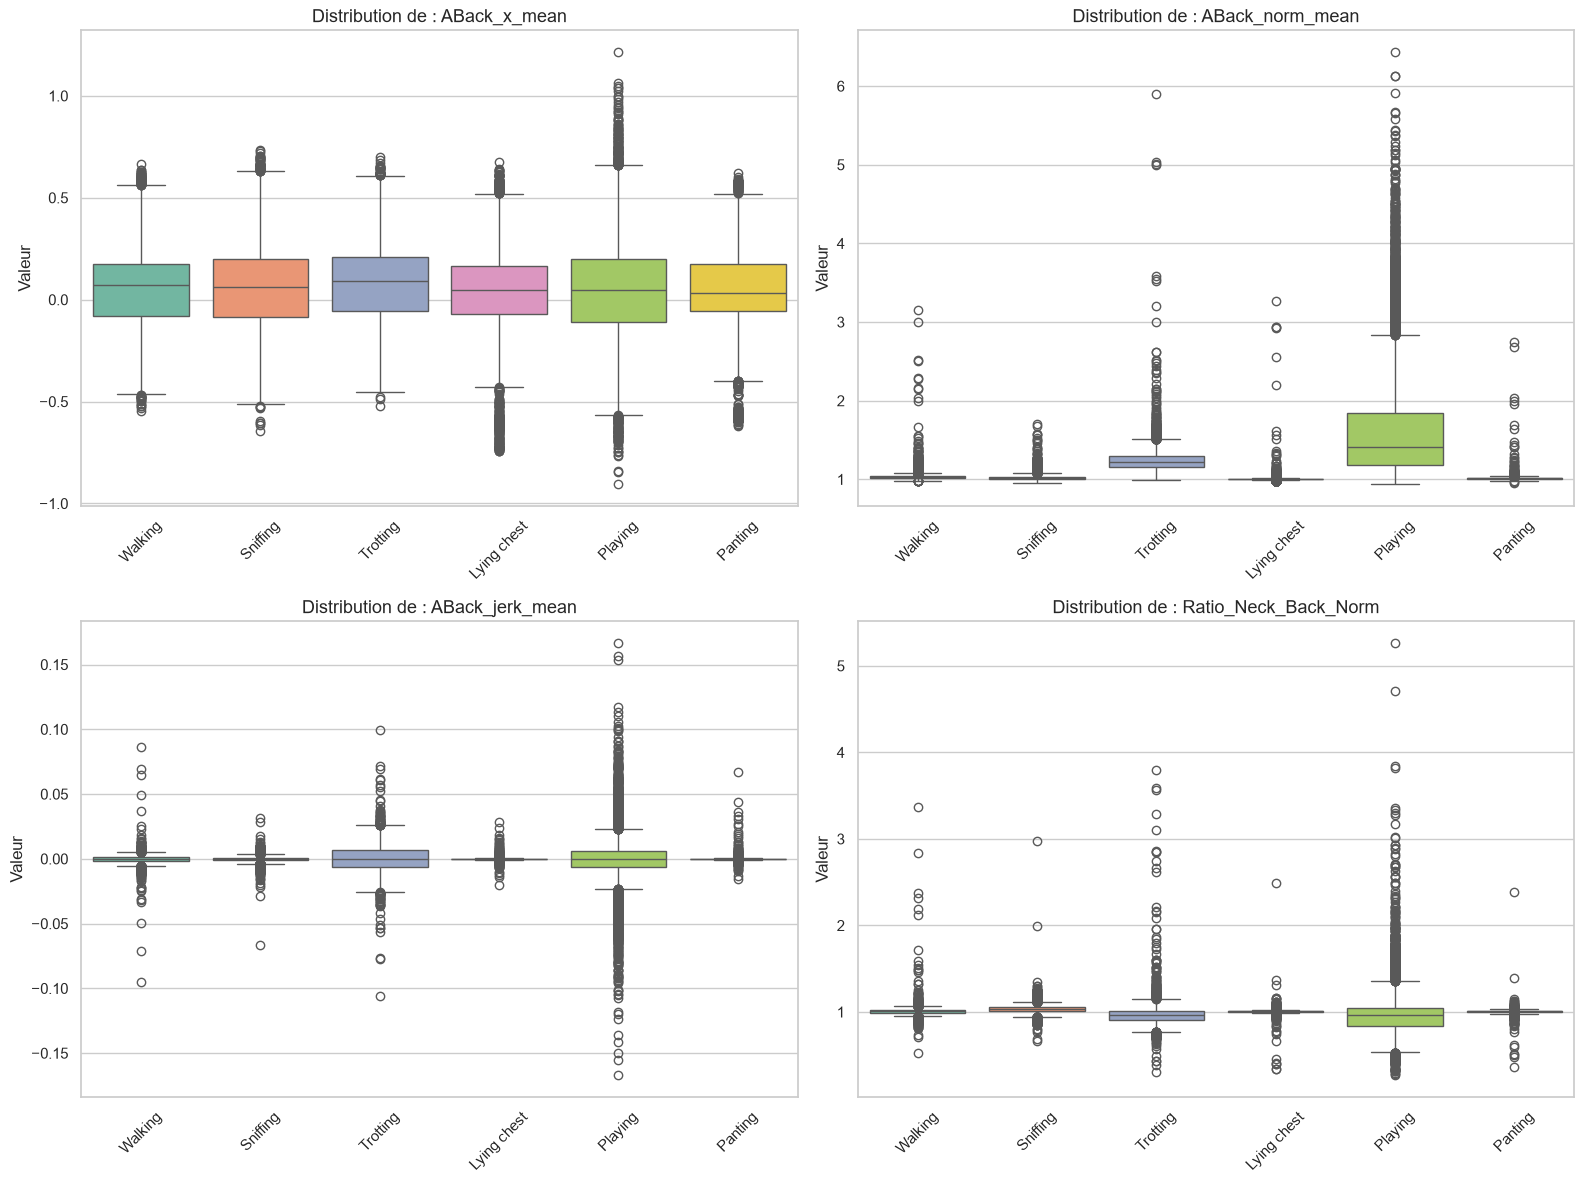

In [42]:
def extraire_features_dynamiques(df_continu, window_size=100, step_size=50):
    """
    Extrait les features sur un enregistrement continu, puis filtre les fenêtres non labellisées.
    window_size = 100 lignes (ex: 1 seconde à 100Hz)
    step_size = 50 lignes (chevauchement de 50%)
    """
    
    # 1. Calcul des features dynamiques sur le signal continu
    # Norme géométrique (Intensité globale du mouvement)
    df_continu['ABack_norm'] = np.sqrt(df_continu['ABack_x']**2 + df_continu['ABack_y']**2 + df_continu['ABack_z']**2)
    df_continu['ANeck_norm'] = np.sqrt(df_continu['ANeck_x']**2 + df_continu['ANeck_y']**2 + df_continu['ANeck_z']**2)
    
    # Jerk (Saccade : différence d'accélération d'un instant à l'autre)
    df_continu['ABack_jerk'] = df_continu['ABack_norm'].diff().fillna(0)
    df_continu['ANeck_jerk'] = df_continu['ANeck_norm'].diff().fillna(0)

    features_list = []
    
    # 2. Fenêtrage glissant
    for i in range(0, len(df_continu) - window_size, step_size):
        window = df_continu.iloc[i : i + window_size]
        
        # 3. Gestion des valeurs manquantes au niveau de la fenêtre
        labels_in_window = window['Behavior_1'].dropna()
        
        # Si moins de 50% de la fenêtre est annotée, on l'ignore (pas de vérité terrain fiable)
        if len(labels_in_window) < (window_size / 2):
            continue
            
        label_majoritaire = labels_in_window.mode().iloc[0]
        
        # 4. Calcul des métriques statistiques pour la fenêtre
        window_features = {
            'DogID': window['DogID'].iloc[0],
            'TestNum': window['TestNum'].iloc[0],
            'Behavior': label_majoritaire,
            
            # Posture et Mouvement basique (Moyenne et Ecart-type sur axe X du dos)
            'ABack_x_mean': window['ABack_x'].mean(),
            'ABack_x_std': window['ABack_x'].std(),
            
            # Intensité absolue (Norme)
            'ABack_norm_mean': window['ABack_norm'].mean(),
            'ABack_norm_std': window['ABack_norm'].std(),
            
            # Saccades (Jerk)
            'ABack_jerk_mean': window['ABack_jerk'].mean(),
            'ABack_jerk_std': window['ABack_jerk'].std(),
            
            # Indice d'indépendance Cou/Dos (ajout de 1e-6 pour éviter la division par zéro)
            'Ratio_Neck_Back_Norm': window['ANeck_norm'].mean() / (window['ABack_norm'].mean() + 1e-6)
        }
        
        features_list.append(window_features)
        
    return pd.DataFrame(features_list)

# 1. Application de l'extraction sur tous les enregistrements continus
list_features = []

# On groupe par chien et par test pour garantir que les fenêtres ne chevauchent pas deux enregistrements distincts
for (dog_id, test_num), group in df_ts.groupby(['DogID', 'TestNum']):
    # On vérifie que le groupe n'est pas vide
    if len(group) > 100:
        df_f = extraire_features_dynamiques(group.copy(), window_size=100, step_size=50)
        list_features.append(df_f)

# Concaténation de toutes les fenêtres extraites en un seul grand DataFrame
df_all_features = pd.concat(list_features, ignore_index=True)
print(f"Extraction terminée : {len(df_all_features)} fenêtres générées au total.\n")

# 2. Sélection des comportements principaux (Top 6) pour éviter un graphique illisible
top_behaviors = df_all_features['Behavior'].value_counts().nlargest(6).index
df_plot = df_all_features[df_all_features['Behavior'].isin(top_behaviors)]

# 3. Liste des features à comparer
features_a_tracer = [
    'ABack_x_mean',         # Posture
    'ABack_norm_mean',      # Intensité globale du dos
    'ABack_jerk_mean',      # Saccades du dos
    'Ratio_Neck_Back_Norm'  # Indépendance Cou/Dos
]

# 4. Création de la grille de Boxplots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_a_tracer):
    sns.boxplot(
        data=df_plot, 
        x='Behavior', 
        y=feature, 
        hue='Behavior', 
        legend=False,
        ax=axes[i], 
        palette='Set2'
    )
    axes[i].set_title(f"Distribution de : {feature}", fontsize=13)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Valeur")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()